<a href="https://www.kaggle.com/code/nazariyyuchnovskiy/model-cvs-tiny-example?scriptVersionId=333205896" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# PseudoAlexNetTiny training and fine-tuning

## Imports to get started

In [1]:
!pip install torchinfo
import torchinfo
import torch
import numpy as np

SEED = 317
BATCH_SIZE = 128

In [2]:
from training import (
    save_checkpoint, 
    load_checkpoint, 
    train_model_stages,
    plot_learning_curves,
    mean_and_std_for_normalization,
    seed_everything,
    seed_worker
)

from evaluation import (
    evaluate_model
)

from fine_tuning import (
    initial_freeze_unfreeze,
    second_unfreeze,
    reset_head_last_fc
)

In [3]:
seed_everything(seed=SEED)

In [4]:
from model import PseudoAlexNet, DEVICE

In [5]:
from natural_images import (
    load_dataset, 
    stratified_three_way_split,
    visualize_dataset_distribution,
    CutMixCollate
)

from screen_images import (
    CustomEnricoDataset,
    plot_image_list
)

## Preparation of the data Caltech101(natural images)

In [16]:
from torchvision.transforms import v2

transforms = v2.Compose([
    v2.Resize((300,200)),
    v2.RGB(),
    v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]),
    v2.Normalize(mean=[np.float32(0.520394), np.float32(0.5027059),np.float32(0.47656456)], 
                 std=[np.float32(0.32288507), np.float32(0.31602064), np.float32(0.32593703)])
    
transforms_augmented_list = [
    v2.RandomResizedCrop(size=(300,200), scale=(0.4,1.0)),
    v2.ColorJitter(),
    v2.RandomErasing(p=1)
]


nat_images = load_dataset(transforms_original=transforms, transforms_augmented_list=transforms_augmented_list),

In [17]:
nat_images_train, nat_images_val, nat_images_test = stratified_three_way_split(dataset=nat_images[0], train_ratio=0.7, 
                                                                             val_ratio=0.15, test_ratio=0.15, random_state=317)

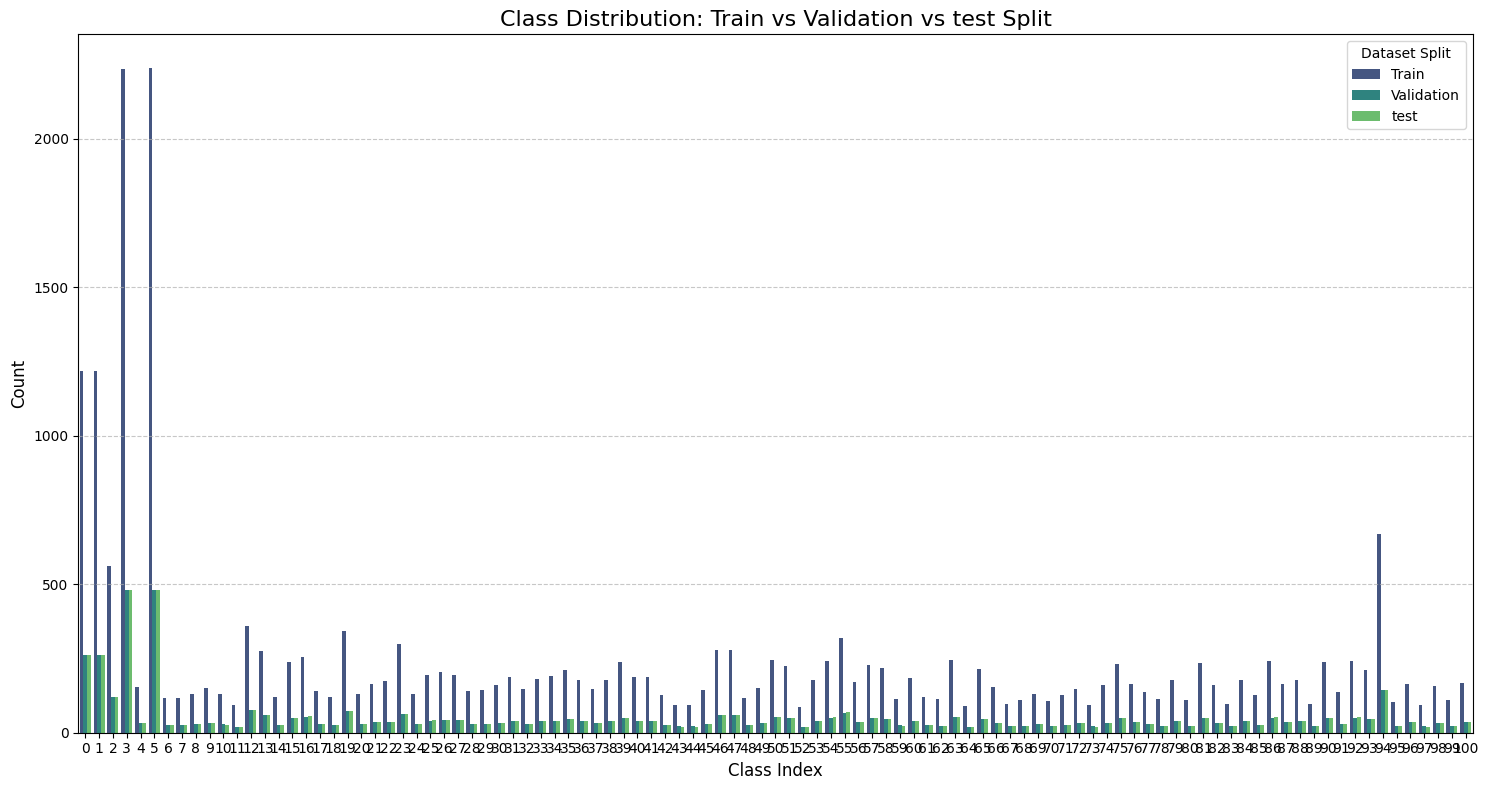

Total Training Samples:   24295 (70.0%)
Total Validation Samples: 5206 (15.0%)
Total test Samples:       5207 (15.0%)
Total Combined Samples:   34708


In [8]:
visualize_dataset_distribution(train_ds=nat_images_train, val_ds=nat_images_val, test_ds=nat_images_test)

In [9]:
g = torch.Generator()
g.manual_seed(SEED)
my_collator = CutMixCollate(num_classes=101, cutmix_prob=0.5)

nat_train_loader = torch.utils.data.DataLoader(nat_images_train, batch_size=BATCH_SIZE, shuffle=True,
                                               num_workers=3, worker_init_fn=seed_worker, 
                                               generator=g, collate_fn=my_collator)

nat_val_loader = torch.utils.data.DataLoader(nat_images_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=3)
nat_test_loader = torch.utils.data.DataLoader(nat_images_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=3)

## Training the model on Caltech101

In [ ]:
import torch.optim as optim
import torch.nn as nn
MAX_NAT_EPOCHS = 50

model = PseudoAlexNet(tiny_factor=3,p=0.4) # with dropout and with LeakyReLU
print(torchinfo.summary(model))
model = model.to(DEVICE)
    
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, eps=1e-5, weight_decay=5e-3)

val_loss_list_nat = []
train_loss_list_nat = []

In [ ]:
train_loss_list_nat, val_loss_list_nat = train_model_stages(model=model, train_loader=nat_train_loader, 
                                                            val_loader=nat_val_loader, optimizer=optimizer, 
                                                            loss_fn=loss_fn, device=DEVICE, max_epochs=MAX_NAT_EPOCHS,
                                                            stage_name="nat_images", patience=7)

evaluate_model(model, nat_test_loader, loss_fn, DEVICE)

## Plotting training and validation test losses

In [ ]:
plot_learning_curves(train_losses=train_loss_list_nat,val_losses=val_loss_list_nat, log_scale=True, 
                     save_to_csv=True, stage="nat_images")

## Preparation of the data Enrico(screen images) - popular classes only

### 1. Defining the transformations and per class transformations for the classes that are underrepresented

In [18]:
from torchvision.transforms import v2
import random
import kornia.augmentation as K

non_identity_perms = [
    [0, 2, 1], # R-B-G
    [1, 0, 2], # G-R-B
    [1, 2, 0], # G-B-R
    [2, 0, 1], # B-R-G
    [2, 1, 0]  # B-G-R
]

forced_channel_shuffle = v2.Lambda(
    lambda x: x.data[random.choice(non_identity_perms), :, :]
)

rare_class_aug = [
    v2.RandomResizedCrop(size=(300,200),
                         scale=(0.4,1.0)),
    v2.ColorJitter(),
    v2.RandomErasing(p=1),
    #K.RandomElasticTransform(p=0.3, kernel_size=(63, 63), sigma=(32.0, 32.0), keepdim=True),
    #K.RandomBoxBlur(p=0.2, keepdim=True)
]

gpu_augmentations = K.AugmentationSequential(
    K.RandomHorizontalFlip(p=0.5),
    K.RandomElasticTransform(p=0.3, kernel_size=(63, 63), sigma=(32.0, 32.0), keepdim=True),
    K.RandomBoxBlur(p=0.2, keepdim=True),
    
    data_keys=["input"],
    keepdim=True
).to(DEVICE)

#fatigue_aug = v2.Compose([
   # v2.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
#])

universal_base = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.uint8, scale=True),
    v2.Resize(size=(300,200)),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[np.float32(0.81179947), np.float32(0.69008505), np.float32(0.76566106)], 
                 std=[np.float32(0.27854076), np.float32(0.35824496), np.float32(0.24417815)], inplace=False)
])

## Preparation of the model for fine-tuning

### 2. Regenerating the train/val/test split for all classes

In [19]:
full_screen_train_dataset, full_screen_val_dataset, full_screen_test_dataset = CustomEnricoDataset.create_splits(
    root="/kaggle/input/datasets/nazariyyuchnovskiy/enricoscreenshotsandwireframes",
    seed=SEED,
    use_wireframes=True,
    transform=universal_base,
    augment_for_each=rare_class_aug,
    allowed_classes=None
)

In [20]:
g = torch.Generator()
g.manual_seed(SEED)
my_collator = CutMixCollate(num_classes=20, cutmix_prob=0.5)
full_screen_train_loader = torch.utils.data.DataLoader(full_screen_train_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                                                       pin_memory=True, num_workers=3, worker_init_fn=seed_worker, 
                                                       generator=g, collate_fn=my_collator)
full_screen_val_loader = torch.utils.data.DataLoader(full_screen_val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True, num_workers=3)
full_screen_test_loader = torch.utils.data.DataLoader(full_screen_test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True, num_workers=3)

### 6. Preparation of the parameters for fine-tuning

In [9]:
MAX_WARMUP_EPOCHS = 15
MAX_DRIFT_EPOCHS = 40

reset_head_last_fc(model, output_features=20)
model = model.to(DEVICE)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=5*1e-5, eps=1e-5, weight_decay=1e-3)
val_loss_list_warmup_2 = []
train_loss_list_warmup_2 = []

val_loss_list_drift_2 = []
train_loss_list_drift_2 = []

NameError: name 'model' is not defined

### 7. Stage 1 of full classes fine-tuning

In [ ]:
initial_freeze_unfreeze(model=model)

train_loss_list_warmup_2, val_loss_list_warmup_2 = train_model_stages(model=model, train_loader=full_screen_train_loader, 
                                                            val_loader=full_screen_val_loader, optimizer=optimizer, 
                                                            loss_fn=loss_fn, device=DEVICE, max_epochs=MAX_WARMUP_EPOCHS,
                                                            stage_name="warmup_2", bn_eval=True, augmenter=gpu_augmentations)

In [ ]:
second_unfreeze(model=model)

for param_group in optimizer.param_groups:
    param_group['lr'] = 1e-4
    
train_loss_list_drift_2, val_loss_list_drift_2 = train_model_stages(model=model, train_loader=full_screen_train_loader, 
                                                            val_loader=full_screen_val_loader, optimizer=optimizer, 
                                                            loss_fn=loss_fn, device=DEVICE, max_epochs=MAX_DRIFT_EPOCHS,
                                                            stage_name="drift_2", bn_eval=True)

evaluate_model(model, full_screen_test_loader, loss_fn, DEVICE)

### Plotting final train/test split

In [ ]:
train_loss_list = train_loss_list_warmup_2 + train_loss_list_drift_2
val_loss_list = val_loss_list_warmup_2 + val_loss_list_drift_2

plot_learning_curves(train_losses=train_loss_list,val_losses=val_loss_list, log_scale=True,
                    save_to_csv=True, stage="drift_2")

## Training the PseudoAlexNetTiny on the Enrico for comparison

In [15]:
import torch.optim as optim
import torch.nn as nn
MAX_SCREEN_EPOCHS = 50

universal_base = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.uint8, scale=True),
    v2.Resize(size=(300,200)),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[np.float32(0.81179947), np.float32(0.69008505), np.float32(0.76566106)], 
                 std=[np.float32(0.27854076), np.float32(0.35824496), np.float32(0.24417815)], inplace=False)
    ])


In [16]:
full_screen_train_dataset, full_screen_val_dataset, full_screen_test_dataset = CustomEnricoDataset.create_splits(
    root="/kaggle/input/datasets/nazariyyuchnovskiy/enricoscreenshotsandwireframes",
    seed=SEED,
    use_wireframes=True,
    transform=universal_base,
    augment_for_each=rare_class_aug,
    allowed_classes=None
)

In [25]:
BATCH_SIZE = 64
g = torch.Generator()
g.manual_seed(SEED)
my_collator = CutMixCollate(num_classes=20, cutmix_prob=0.5)
full_screen_train_loader = torch.utils.data.DataLoader(full_screen_train_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                                                       pin_memory=True, num_workers=3, worker_init_fn=seed_worker,
                                                       generator=g, collate_fn=my_collator)
full_screen_val_loader = torch.utils.data.DataLoader(full_screen_val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True, num_workers=3)
full_screen_test_loader = torch.utils.data.DataLoader(full_screen_test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True, num_workers=3)

In [26]:
!pip install sam-pytorch
from sam import SAM
model = PseudoAlexNet(tiny_factor=2, p=0.4, negative_slope=0.1) # with dropout and with LeakyReLU

loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)
reset_head_last_fc(model, output_features=20)
model = model.to(DEVICE)

optimizer = optim.AdamW(model.parameters(), lr=2e-3, eps=1e-5, weight_decay=1e-3)
#optimizer = optim.SGD(model.parameters(), lr=5e-4, momentum=0.9, weight_decay=1e-3)
optimizer = SAM(
    model.parameters(), 
    optimizer, 
    rho=0.1,
)

val_loss_list_screen = []
train_loss_list_screen = []

print(torchinfo.summary(model))

Layer (type:depth-idx)                   Param #
PseudoAlexNet                            --
├─Sequential: 1-1                        --
│    └─ConvBN2d: 2-1                     --
│    │    └─Conv2d: 3-1                  456
│    │    └─BatchNorm2d: 3-2             12
│    └─ConvBN2d: 2-2                     --
│    │    └─Conv2d: 3-3                  440
│    │    └─BatchNorm2d: 3-4             16
│    └─MaxPool2d: 2-3                    --
│    └─ConvBN2d: 2-4                     --
│    │    └─Conv2d: 3-5                  876
│    │    └─BatchNorm2d: 3-6             24
│    └─ConvBN2d: 2-5                     --
│    │    └─Conv2d: 3-7                  1,744
│    │    └─BatchNorm2d: 3-8             32
│    └─MaxPool2d: 2-6                    --
├─Sequential: 1-2                        --
│    └─Dropout: 2-7                      --
│    └─Linear: 2-8                       3,789,056
│    └─BatchNorm1d: 2-9                  512
│    └─LeakyReLU: 2-10                   --
│    └─Dropou

In [ ]:
import warnings
warnings.filterwarnings("ignore")

train_loss_list_screen, val_loss_list_screen = train_model_stages(model=model, train_loader=full_screen_train_loader, 
                                                            val_loader=full_screen_val_loader, optimizer=optimizer, 
                                                            loss_fn=loss_fn, device=DEVICE, max_epochs=MAX_SCREEN_EPOCHS,
                                                            stage_name="screen", bn_eval=False, augmenter=gpu_augmentations)

=== Training on the screen ===
Starting training of the screen in 50 epochs.
 screen training epoch 1/50...
Train Epoch: 1 [0/8192 (0%)]	Loss: 3.284769
Train Epoch: 1 [192/8192 (5%)]	Loss: 2.826917
Train Epoch: 1 [384/8192 (9%)]	Loss: 2.806655
Train Epoch: 1 [576/8192 (14%)]	Loss: 2.540078
Train Epoch: 1 [768/8192 (19%)]	Loss: 2.731759
Train Epoch: 1 [960/8192 (23%)]	Loss: 2.451116
Train Epoch: 1 [1152/8192 (28%)]	Loss: 2.760474
Train Epoch: 1 [1344/8192 (33%)]	Loss: 2.730603
Train Epoch: 1 [1536/8192 (38%)]	Loss: 2.892260
Train Epoch: 1 [1728/8192 (42%)]	Loss: 2.315246
Train Epoch: 1 [1920/8192 (47%)]	Loss: 2.609894
Train Epoch: 1 [2112/8192 (52%)]	Loss: 2.602084
Train Epoch: 1 [2304/8192 (56%)]	Loss: 2.537251
Train Epoch: 1 [2496/8192 (61%)]	Loss: 2.447862
Train Epoch: 1 [2688/8192 (66%)]	Loss: 2.297442
Train Epoch: 1 [2880/8192 (70%)]	Loss: 2.418663
Train Epoch: 1 [3072/8192 (75%)]	Loss: 1.884637
Train Epoch: 1 [3264/8192 (80%)]	Loss: 2.402673
Train Epoch: 1 [3456/8192 (84%)]	Loss: 

In [ ]:
evaluate_model(model, full_screen_test_loader, loss_fn, DEVICE)

plot_learning_curves(train_losses=train_loss_list_screen,val_losses=val_loss_list_screen, log_scale=True,
                    save_to_csv=True, stage="screen_images")